# Report visualisations — windstorm (Kazakhstan)

In [ ]:
import re

storm_name          = "buran_nov2023"
oblast_filter       = "Pavlodar Region" 
BUILT_UP_CURVE      = 'weakest outbuilding'
MAXDAM_BUILT_UP_USD = 452.0
PIXEL_AREA_M2       = 100 * 100

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import rasterio
import matplotlib.pyplot as plt
import contextily as ctx
from rasterstats import zonal_stats

In [ ]:
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)  
OBLAST_FIELD = 'oblast_en'
curves_path  = Path('CURVES_feuerstein_koks.csv') 

work_dir        = Path('.')
hazard_data_dir = work_dir / 'STORM_event_raster' / f'data_{storm_name}'
risk_dir        = work_dir / 'STORM_risk'
data_dir        = risk_dir / 'data'
results_dir     = risk_dir / 'results'
report_dir      = risk_dir / 'plots' / 'report'
report_dir.mkdir(parents=True, exist_ok=True)

region_name = re.sub(r'[^a-zA-Z0-9]', '', oblast_filter) if oblast_filter else 'Kazakhstan'

In [ ]:
kaz = gpd.read_file(SHAPEFILE_PATH)
if oblast_filter is not None:
    region_gdf = kaz[kaz[OBLAST_FIELD] == oblast_filter].dissolve()
    districts  = kaz[kaz[OBLAST_FIELD] == oblast_filter].copy()
else:
    region_gdf = gpd.GeoDataFrame(geometry=[kaz.geometry.union_all()], crs=kaz.crs)
    districts  = kaz.copy()

footprint_path    = hazard_data_dir / f'{storm_name}.nc'
lc_path           = data_dir / f'land_cover_ESA_WC_{region_name}.tif'
wind_matched_path = data_dir / f'windstorm_matched_{storm_name}_{region_name}.tif'
dmg_path          = results_dir / f'wind_{storm_name}_{region_name}_damagemap.tif'
rel_dmg_path      = results_dir / f'wind_{storm_name}_{region_name}_reldamagemap.tif'

for p in [footprint_path, lc_path, wind_matched_path, dmg_path, rel_dmg_path, curves_path]:
    if not p.exists():
        raise FileNotFoundError(f'Required file not found: {p}')

footprint = rxr.open_rasterio(str(footprint_path), masked=True).squeeze()
footprint.rio.write_crs('EPSG:4326', inplace=True)

curves_feuerstein = pd.read_csv(curves_path, index_col=0)
curves_feuerstein.columns = curves_feuerstein.columns.str.strip()
curves_feuerstein = curves_feuerstein.rename(columns={'concrete buidling': 'concrete building'})
curves_feuerstein = curves_feuerstein / 100.0
wind_speeds_axis  = curves_feuerstein.index.astype(float).values

with rasterio.open(wind_matched_path) as src:
    wind_arr = src.read(1).astype(float)
    wind_arr[wind_arr <= 0] = np.nan

with rasterio.open(lc_path) as src:
    lc_arr = src.read(1).astype(float)

with rasterio.open(dmg_path) as src:
    dmg_arr = src.read(1).astype(float)

with rasterio.open(rel_dmg_path) as src:
    rel_arr = src.read(1).astype(float)

mask_built = (lc_arr == 50) & ~np.isnan(wind_arr)

print(f'Storm        : {storm_name}')
print(f'Region       : {region_name}')
print(f'Wind matched : {wind_arr.shape}')
print(f'Built pixels : {mask_built.sum():,}')

gust_stats = zonal_stats(
    districts,
    str(footprint_path),
    stats=['mean', 'max'],
    nodata=np.nan,
)
districts = districts.copy()
districts['mean_gust'] = [s['mean'] for s in gust_stats]
districts['max_gust']  = [s['max']  for s in gust_stats]

dmg_stats = zonal_stats(
    districts,
    str(dmg_path),
    stats=['sum'],
    nodata=0,
)
districts['total_dmg_mln'] = [
    (s['sum'] or 0) * PIXEL_AREA_M2 / 1e6 for s in dmg_stats
]

Storm        : buran_nov2023
Region       : PavlodarRegion
Wind matched : (8283, 10017)
Built pixels : 245,223


## Figure 1 — Hazard intensity by district

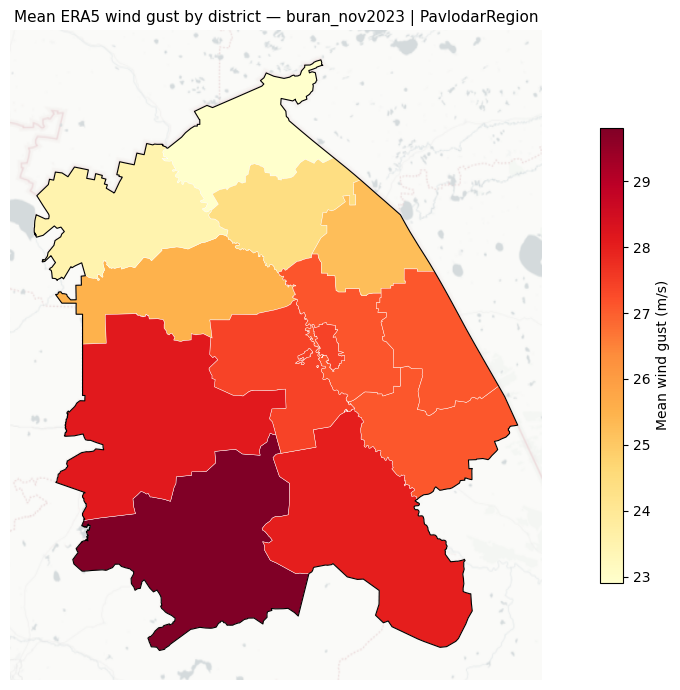

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
districts.plot(
    column='mean_gust', ax=ax, cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'Mean wind gust (m/s)', 'shrink': 0.7},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    edgecolor='white', linewidth=0.3,
)
region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
try:
    ctx.add_basemap(ax=ax, crs='EPSG:4326',
                    source=ctx.providers.CartoDB.Positron, attribution=False)
except Exception:
    pass 
ax.set_title(f'Mean ERA5 wind gust by district — {storm_name} | {region_name}', fontsize=11)
ax.set_axis_off()
plt.tight_layout()
fig.savefig(report_dir / f'Fig1_HazardIntensity_{storm_name}_{region_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Wind speed pixel distribution

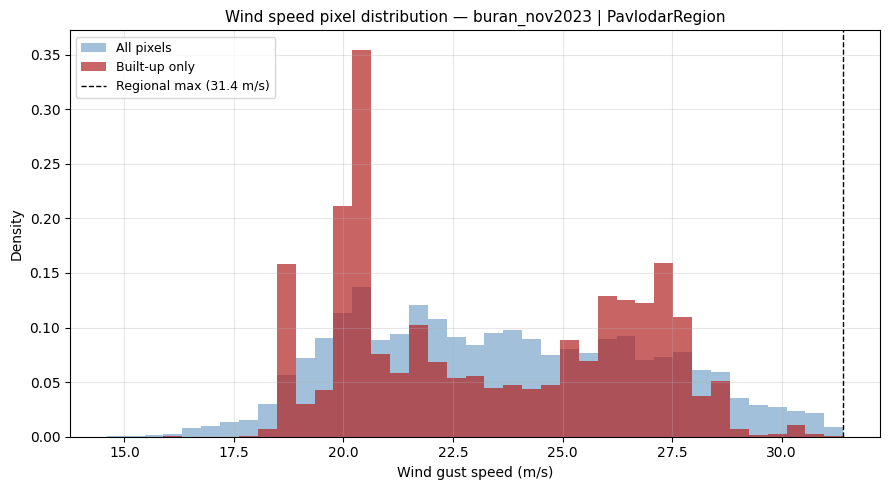

In [7]:
wind_all   = wind_arr[~np.isnan(wind_arr)].ravel()
wind_built = wind_arr[mask_built].ravel()
bins = np.linspace(np.nanmin(wind_arr), np.nanmax(wind_arr), 40)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(wind_all,   bins=bins, alpha=0.5, color='steelblue', label='All pixels',    density=True)
ax.hist(wind_built, bins=bins, alpha=0.7, color='firebrick', label='Built-up only', density=True)
ax.axvline(np.nanmax(wind_arr), color='black', linestyle='--', linewidth=1,
           label=f'Regional max ({np.nanmax(wind_arr):.1f} m/s)')
ax.set_xlabel('Wind gust speed (m/s)')
ax.set_ylabel('Density')
ax.set_title(f'Wind speed pixel distribution — {storm_name} | {region_name}', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(report_dir / f'Fig2_WindDistribution_{storm_name}_{region_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Built-up area exceedance curve

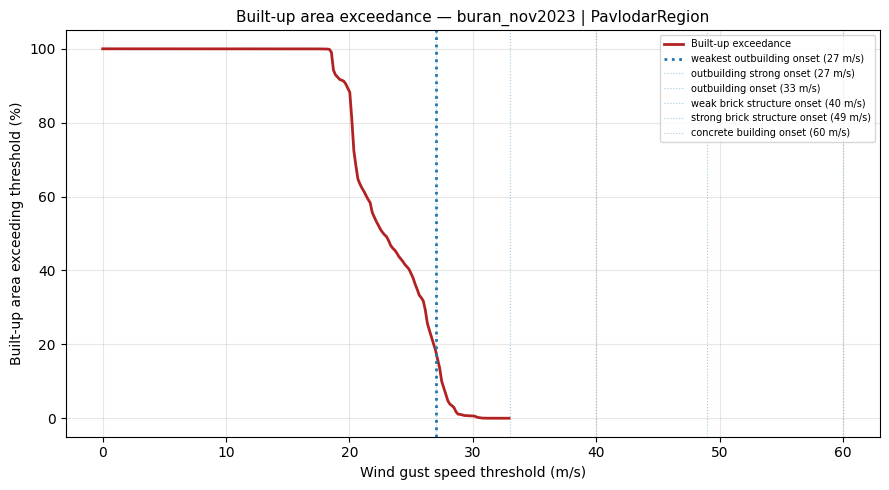

In [ ]:
thresholds  = np.linspace(0, np.nanmax(wind_built) * 1.05, 200)
n_built     = mask_built.sum()
exceed_pct  = np.array([(wind_built >= t).sum() / n_built * 100 for t in thresholds])

onset = {}
for col in curves_feuerstein.columns:
    nonzero = curves_feuerstein.index[curves_feuerstein[col] > 0]
    onset[col] = float(nonzero[0]) if len(nonzero) else None

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, exceed_pct, color='firebrick', linewidth=2, label='Built-up exceedance')
for col, v in onset.items():
    if v is not None:
        lw    = 2.0 if col == BUILT_UP_CURVE else 0.8
        alpha = 1.0 if col == BUILT_UP_CURVE else 0.4
        ax.axvline(v, linestyle=':', linewidth=lw, alpha=alpha,
                   label=f'{col} onset ({v:.0f} m/s)')
ax.set_xlabel('Wind gust speed threshold (m/s)')
ax.set_ylabel('Built-up area exceeding threshold (%)')
ax.set_title(f'Built-up area exceedance — {storm_name} | {region_name}', fontsize=11)
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(report_dir / f'Fig3_Exceedance_{storm_name}_{region_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Feuerstein wind vulnerability curves

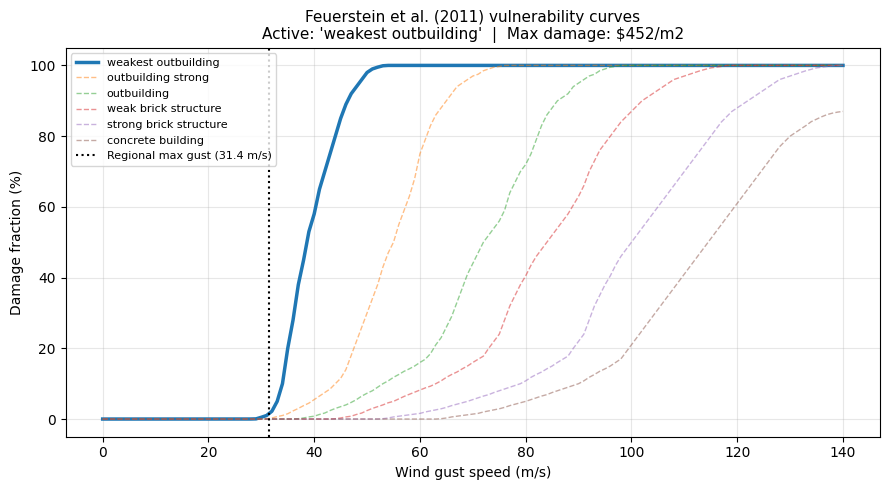

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for col in curves_feuerstein.columns:
    lw    = 2.5 if col == BUILT_UP_CURVE else 1.0
    ls    = '-'  if col == BUILT_UP_CURVE else '--'
    alpha = 1.0  if col == BUILT_UP_CURVE else 0.5
    ax.plot(curves_feuerstein.index, curves_feuerstein[col] * 100,
            label=col, linewidth=lw, linestyle=ls, alpha=alpha)
ax.axvline(np.nanmax(wind_built), color='black', linestyle=':', linewidth=1.5,
           label=f'Regional max gust ({np.nanmax(wind_built):.1f} m/s)')
ax.set_xlabel('Wind gust speed (m/s)')
ax.set_ylabel('Damage fraction (%)')
ax.set_title(
    f'Feuerstein et al. (2011) vulnerability curves\n'
    f'Active: {BUILT_UP_CURVE!r}  |  Max damage: ${MAXDAM_BUILT_UP_USD:.0f}/m2',
    fontsize=11,
)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(report_dir / f'Fig4_VulnerabilityCurves_{storm_name}_{region_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 5 — Damage sensitivity to curve choice

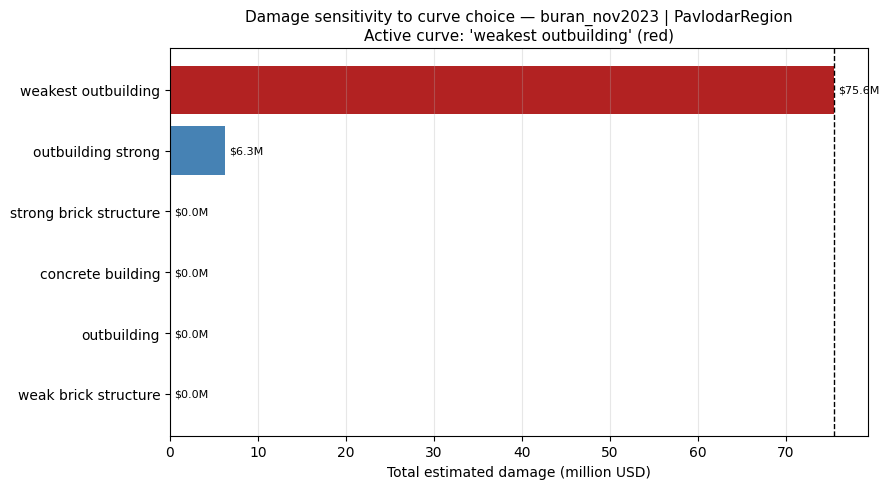

In [10]:
total_by_curve = {}
for col in curves_feuerstein.columns:
    frac = np.interp(wind_arr[mask_built], wind_speeds_axis, curves_feuerstein[col].values)
    total_by_curve[col] = frac.sum() * MAXDAM_BUILT_UP_USD * PIXEL_AREA_M2 / 1e6

dam_series = pd.Series(total_by_curve).sort_values(ascending=True)
colors = ['firebrick' if c == BUILT_UP_CURVE else 'steelblue' for c in dam_series.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(dam_series.index, dam_series.values, color=colors)
ax.axvline(dam_series[BUILT_UP_CURVE], color='black', linestyle='--', linewidth=1)
ax.bar_label(bars, fmt='$%.1fM', padding=3, fontsize=8)
ax.set_xlabel('Total estimated damage (million USD)')
ax.set_title(
    f'Damage sensitivity to curve choice — {storm_name} | {region_name}\n'
    f'Active curve: {BUILT_UP_CURVE!r} (red)',
    fontsize=11,
)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(report_dir / f'Fig5_DamageSensitivity_{storm_name}_{region_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 6 — Total damage by district

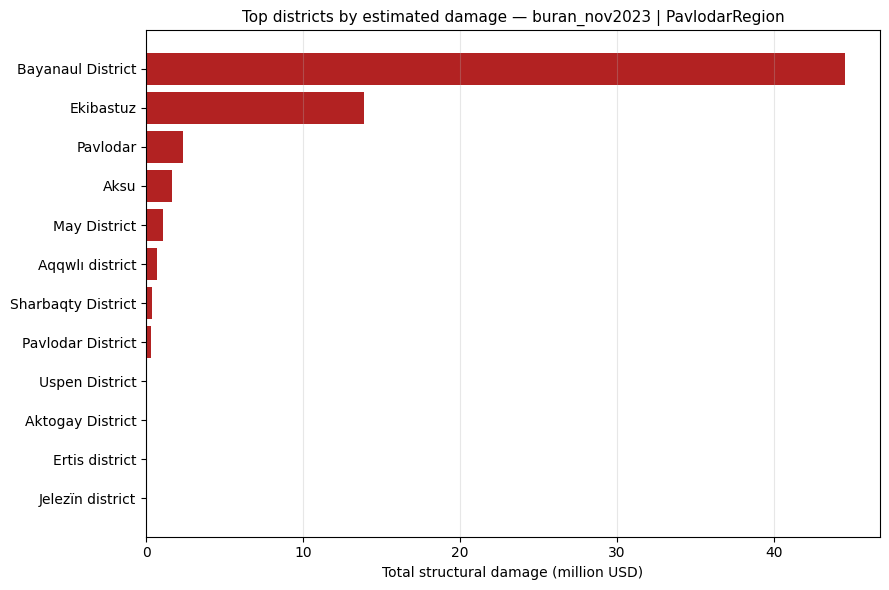

In [11]:
top_n = (
    districts[['name_en', 'total_dmg_mln']]
    .nlargest(12, 'total_dmg_mln')
    .sort_values('total_dmg_mln')
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_n['name_en'], top_n['total_dmg_mln'], color='firebrick')
ax.set_xlabel('Total structural damage (million USD)')
ax.set_title(f'Top districts by estimated damage — {storm_name} | {region_name}', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(report_dir / f'Fig6_DamageByDistrict_{storm_name}_{region_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 7 — District damage vs mean wind gust

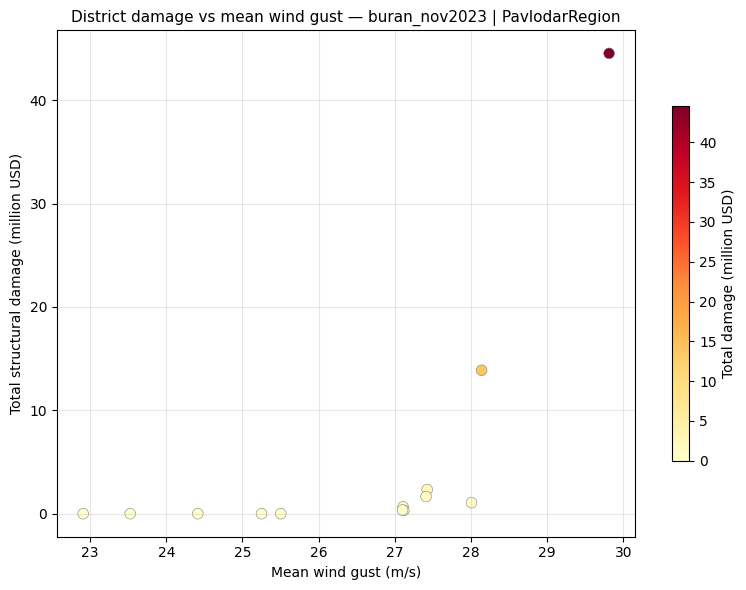

In [12]:
plot_df = districts[['name_en', 'mean_gust', 'total_dmg_mln']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    plot_df['mean_gust'], plot_df['total_dmg_mln'],
    c=plot_df['total_dmg_mln'], cmap='YlOrRd',
    edgecolors='grey', linewidth=0.4, s=60,
)
plt.colorbar(sc, ax=ax, label='Total damage (million USD)', shrink=0.7)
ax.set_xlabel('Mean wind gust (m/s)')
ax.set_ylabel('Total structural damage (million USD)')
ax.set_title(f'District damage vs mean wind gust — {storm_name} | {region_name}', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(report_dir / f'Fig7_DamageVsGust_{storm_name}_{region_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 8 — Summary infographic panel

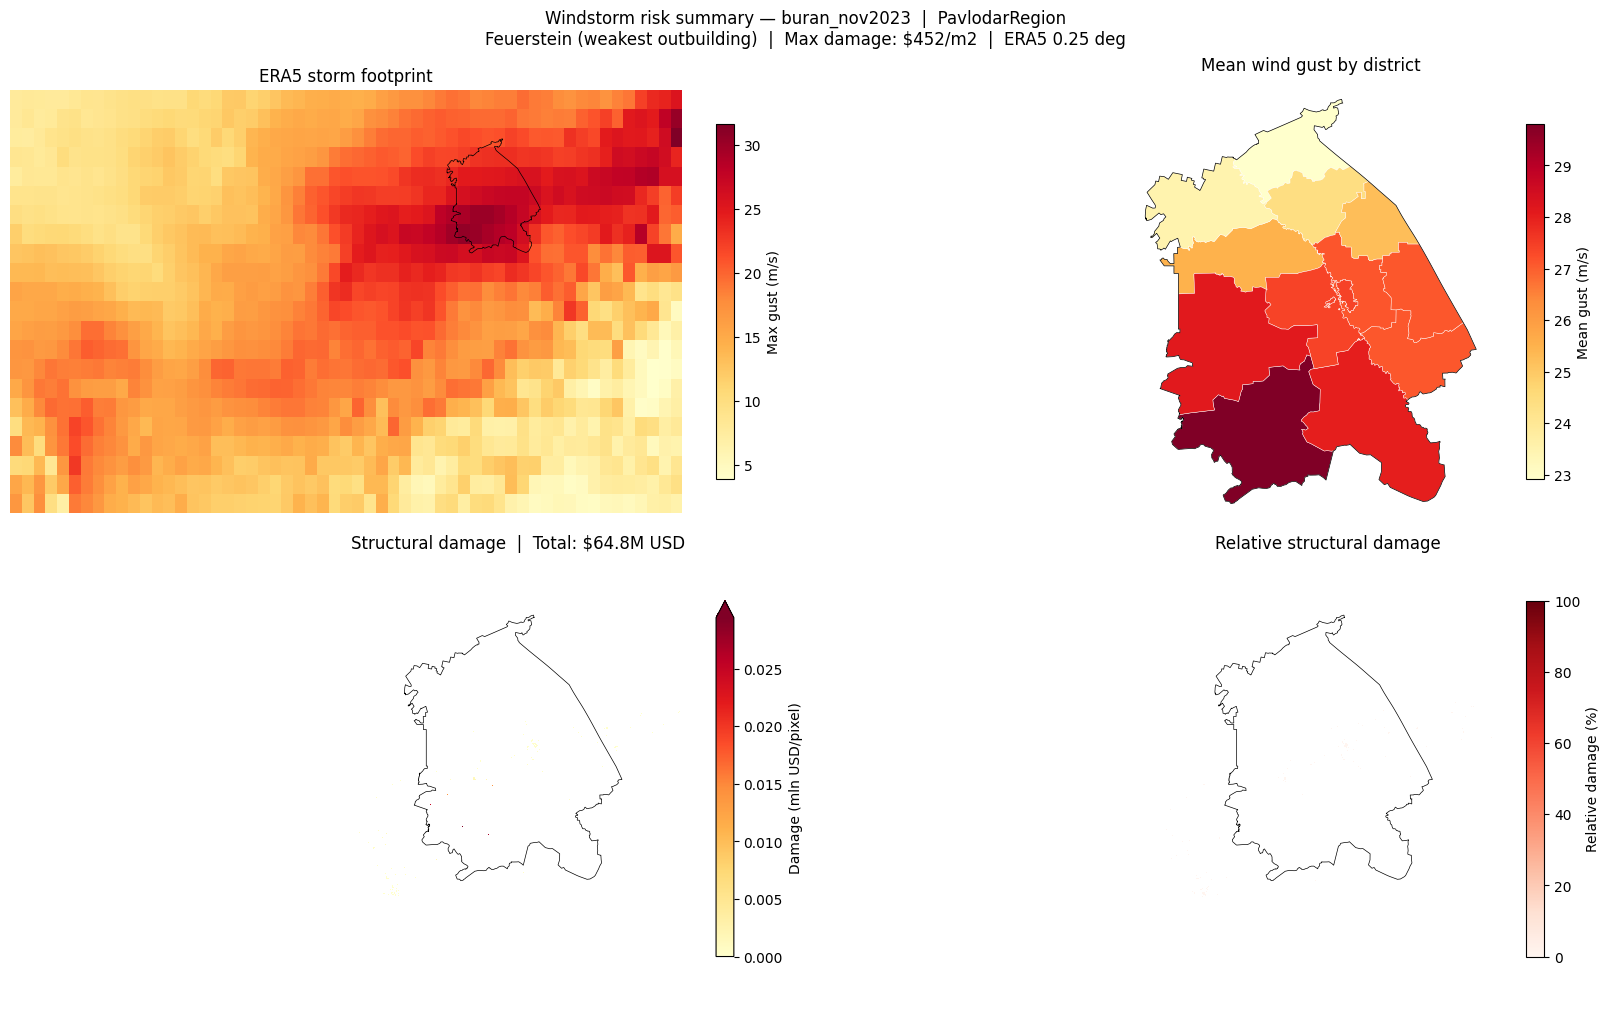

All figures saved to: STORM_risk\plots\report


In [13]:
dmg_rxr = rxr.open_rasterio(dmg_path).squeeze()
dmg_rxr = dmg_rxr.where(dmg_rxr > 0) * PIXEL_AREA_M2 / 1e6
rel_rxr = rxr.open_rasterio(rel_dmg_path).squeeze()
rel_rxr = rel_rxr.where(rel_rxr > 0) * 100

STEP     = 3
vmax_dmg = float(np.nanpercentile(dmg_rxr.values[dmg_rxr.values > 0], 99)) \
           if (dmg_rxr.values > 0).any() else 0.001
total_dmg_mln = districts['total_dmg_mln'].sum()

fig, axs = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

footprint.isel(x=slice(None, None, STEP), y=slice(None, None, STEP)).plot(
    ax=axs[0, 0], cmap='YlOrRd',
    cbar_kwargs={'label': 'Max gust (m/s)', 'shrink': 0.8},
)
axs[0, 0].set_title('ERA5 storm footprint')

districts.plot(
    column='mean_gust', ax=axs[0, 1], cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'Mean gust (m/s)', 'shrink': 0.8},
    missing_kwds={'color': 'lightgrey'},
    edgecolor='white', linewidth=0.3,
)
axs[0, 1].set_title('Mean wind gust by district')

dmg_rxr.isel(x=slice(None, None, STEP), y=slice(None, None, STEP)).plot(
    ax=axs[1, 0], cmap='YlOrRd', vmin=0, vmax=vmax_dmg,
    cbar_kwargs={'label': 'Damage (mln USD/pixel)', 'shrink': 0.8},
)
axs[1, 0].set_title(f'Structural damage  |  Total: ${total_dmg_mln:.1f}M USD')

rel_rxr.isel(x=slice(None, None, STEP), y=slice(None, None, STEP)).plot(
    ax=axs[1, 1], cmap='Reds', vmin=0, vmax=100,
    cbar_kwargs={'label': 'Relative damage (%)', 'shrink': 0.8},
)
axs[1, 1].set_title('Relative structural damage')

for ax in axs.flat:
    region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
    ax.set_axis_off()

fig.suptitle(
    f'Windstorm risk summary — {storm_name}  |  {region_name}\n'
    f'Feuerstein ({BUILT_UP_CURVE})  |  Max damage: ${MAXDAM_BUILT_UP_USD:.0f}/m2  |  ERA5 0.25 deg',
    fontsize=12,
)
fig.savefig(report_dir / f'Fig8_SummaryPanel_{storm_name}_{region_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'All figures saved to: {report_dir}')